<a href="https://colab.research.google.com/github/Rachit1801/aditi/blob/main/AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Goal**
- numpy

- pandas

- matplotlib

- scikit-learn

In [ ]:
#numpy
import numpy as np
np.array([1,2,3])
np.zeros((3,4))
np.ones((2,2))
np.eye(3)  #identity matrix 3x3
np.arange(0, 10, 2)   #including 0,not including 10
np.linspace(0, 1, 5)    #5 eleemts between 0 and 1
np.random.rand(3,3)
np.random.randn(3,3)
np.random.randint(1, 10, (3,3))


array([[1, 8, 1],
       [3, 8, 9],
       [1, 9, 5]])

In [ ]:
a = np.array([[1,2,3],[4,5,6]])
a.shape
a.ndim
a.size
a.dtype


dtype('int64')

In [ ]:
#indexing and slicing

a[0]
a[1,2]
a[:, 1]
a[1:3, :]


array([[4, 5, 6]])

In [ ]:
#boolean indexing

a[a > 5]
a[(a > 2) & (a < 8)]


array([3, 4, 5, 6])

In [ ]:
#broad casting

a = np.array([[1,2,3],[4,5,6]])
b = np.array([1,2,3])

a + b

array([[2, 4, 6],
       [5, 7, 9]])

In [ ]:
np.sum(a)
np.mean(a)
np.std(a)
np.min(a)
np.max(a)

np.sum(a, axis=0)  # column-wise
#np.sum(a, axis=1)  # row-wise

np.int64(10)

In [ ]:
a.reshape(2,3)
a.flatten()   #flatten() always returns a new copy of the array, while ravel() returns a view of the original array
a.ravel()     # = a.reshape(-1)

np.vstack((a,b))
#np.hstack((a,b))

array([[1, 2, 3],
       [4, 5, 6],
       [1, 2, 3]])

In [ ]:
a = 10
np.sqrt(a)
np.exp(a)
np.log(a)

np.float64(2.302585092994046)

#Titanic

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


Random Forest Accuracy: 0.80


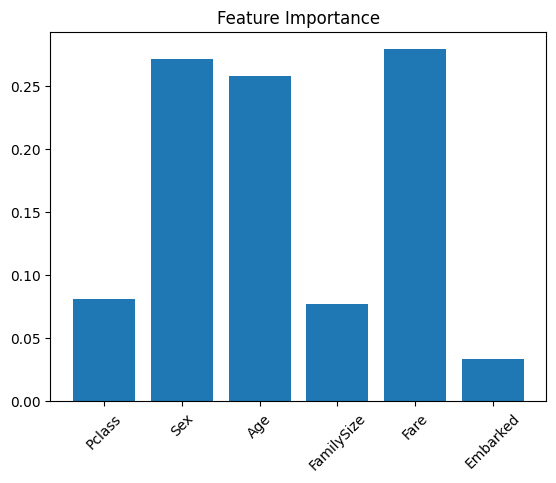

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

df = df.drop(['Name', 'Ticket', 'Cabin','PassengerId'], axis=1)
#Drop data instead of filling it : df = df.dropna()

#Filling with most common value
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#mapping
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

#Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df = df.drop(['SibSp','Parch'], axis=1)

x = df[['Pclass', 'Sex', 'Age', 'FamilySize' , 'Fare', 'Embarked']]
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

print(f'Random Forest Accuracy: {accuracy:.2f}')

# Feature Importance
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = x.columns

plt.figure()
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.8100558659217877


In [ ]:
### Now we can use the model to make predictions based on user input
passclass = int(input("class (1, 2, or 3): "))
sex = int(input("sex (male = 0 or female = 1): "))
age = int(input(" age: "))
fs = int(input("Family Size : "))
fare = float(input("fare: "))
embarked = int(input("Southampton:0 Cherbourg:1 Queenstown:2 "))

new_data = pd.DataFrame([[passclass, sex, age, fs , fare, embarked]],columns=['Pclass', 'Sex', 'Age', 'FamilySize', 'Fare', 'Embarked'])

probs = model.predict_proba(new_data)
print(f'Prediction: {probs[0][1]:.2f} probability of survival.')
if probs[0][1] > 0.5:
    print("The passenger is likely to survive.")

class (1, 2, or 3): 3
sex (male = 0 or female = 1): 1
 age: 5
Family Size : 3
fare: 10
Southampton:0 Cherbourg:1 Queenstown:2 0
Prediction: 0.50 probability of survival.


## RandomForestClassifier
- safe default ML weapon <br>
- It builds many decision trees and combines them.<br>
## What is n_estimators?

Number of trees in the forest.

- 1 tree → weak
- 10 trees → better
- 100 trees → strong
- 1000 trees → slower but maybe slightly better

More trees:

- More stable predictions
- Lower variance
- More computation time
- 100 is a common default.


